In [1]:
import numpy as np
import torch
import utils as ut
import torch.nn as nn
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot as plt
from scipy.special import gamma as gamma_func
from scipy.optimize import brentq
from utils import get_filepath
from binary_classifier import BinaryClassifier
plt.rc('axes', prop_cycle=plt.cycler(color=plt.get_cmap('Set1').colors))

In [2]:
config = {
    "data": {
        "parameter_range": (0, 10),
        "std": 1.,
        #"likelihood_prior_sampling_ratio": 1,
        "n_parameters": 1,
        "n_train": 70_000,
        "n_test": 15_000,
        "n_validation": 15_000
    },
    "classifier": {
        "n_inputs": 1,
        "n_hidden_layers": 3,
        "n_units": 64
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 128,
        "n_epochs": 5,
        "model_iterations": 1
    }
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)


#### Prior Distirbutions:

In [3]:
def normalize(function, lower, upper):
    x = np.linspace(lower, upper, 1000)
    integral = np.trapezoid(function(x), x)
    def result_fct(z): return function(z) / integral
    result_fct.__name__ = function.__name__
    return result_fct

def uniform(x, min_val=0, max_val=10):
    return 1 / (max_val - min_val) if min_val <= x <= max_val else 0.

def normal(x, mean=5, std=4):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))

def exponential(x, lam=.3):
    return lam * np.exp(-lam * x) if x >= 0 else 0.

def gamma(x, shape=2, scale=2):
    return (x ** (shape - 1) * np.exp(-x / scale)) / (scale ** shape * gamma_func(shape)) if x >= 0 else 0.

def sinusoidal(x, frequency=3, offset=5):
    return np.sin(frequency * x) + offset

priors = [uniform, normal, exponential, gamma, sinusoidal]
priors = [normalize(np.vectorize(f), *config["data"]["parameter_range"]) for f in priors]

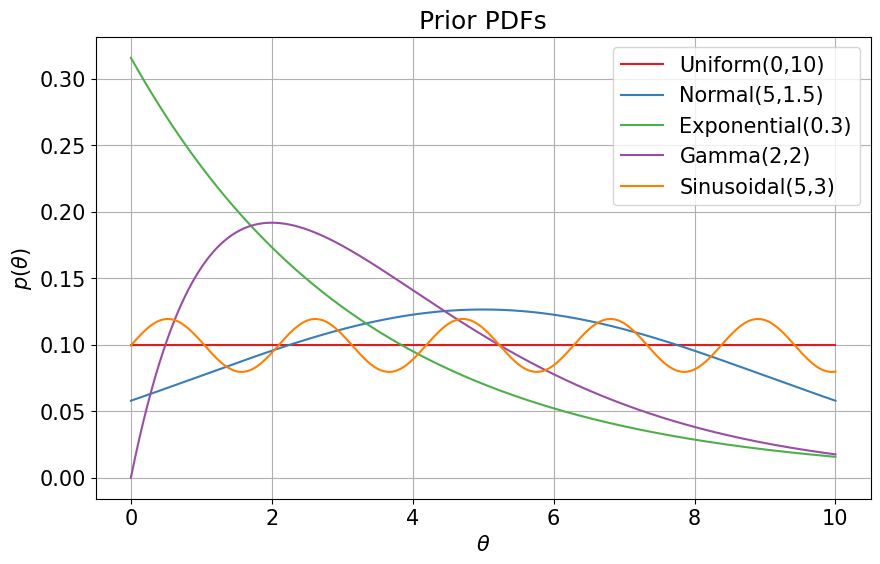

In [4]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(config["data"]["parameter_range"][0], config["data"]["parameter_range"][1], 1000)
prior_labels = ["Uniform(0,10)", "Normal(5,1.5)", "Exponential(0.3)", "Gamma(2,2)", "Sinusoidal(5,3)"]
for prior, label in zip(priors, prior_labels):
    ax.plot(x, prior(x), label=label)
ax.legend()
ax.set_title("Prior PDFs")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("$p(\\theta)$")
ax.grid()
fig.savefig("figs/toy_priors.svg")
pass

In [5]:
# check normalization of priors
x = np.linspace(config["data"]["parameter_range"][0], config["data"]["parameter_range"][1], 1000)
for prior in priors:
    print(f"Integral of {prior.__name__}: {np.trapezoid(prior(x), x)}")

Integral of uniform: 1.0
Integral of normal: 1.0
Integral of exponential: 1.0
Integral of gamma: 1.0
Integral of sinusoidal: 1.0


#### Data:

In [6]:
def sample_from_pdf(pdf, n_samples, x_min, x_max):
    x_values = np.linspace(x_min, x_max, int(1e4))
    pdf_values = pdf(x_values)
    cdf_values = np.cumsum(pdf_values)
    cdf_values /= cdf_values[-1]

    random_values = generator.uniform(0, 1, n_samples)
    sampled_x = np.interp(random_values, cdf_values, x_values)
    return sampled_x

def get_data(prior, show_output=True):
    data_config = config["data"]
    total_data_points = data_config["n_train"] + data_config["n_test"] + data_config["n_validation"]
    n_class = total_data_points // 2

    #labels
    labels = np.hstack((np.zeros(n_class), np.ones(n_class)))

    #parameters
    #parameters_all = generator.uniform(low=data_config["parameter_range"][0], high=data_config["parameter_range"][1], size=3*n_class)
    parameters_all = sample_from_pdf(prior, 3*n_class, data_config["parameter_range"][0], data_config["parameter_range"][1])
    parameters_dependent = parameters_all[:n_class]
    parameters_independent = parameters_all[n_class:2*n_class]
    parameters_random = parameters_all[2*n_class:]
    parameters = np.hstack((parameters_independent, parameters_dependent))

    #data
    data_0 = generator.normal(loc=parameters_random, scale=data_config["std"], size=n_class)
    data_1 = generator.normal(loc=parameters_dependent, scale=data_config["std"], size=n_class)
    data = np.hstack((data_0, data_1))

    #shuffle:
    idx = np.arange(2*(n_class))
    generator.shuffle(idx)
    data, labels, parameters = [torch.tensor(x[idx]).float() for x in (data, labels, parameters)]

    #split:
    n_train, n_test, n_validation = data_config["n_train"], data_config["n_test"], data_config["n_validation"]
    all_information = (data, labels, parameters)
    data_train, labels_train, parameters_train, = [x[:n_train] for x in all_information]
    data_test, labels_test, parameters_test, = [x[n_train:n_train+n_test] for x in all_information]
    data_validation, labels_validation, parameters_validation, = [x[n_train+n_test:n_train+n_test+n_validation] for x in all_information]

    if show_output:
        print(f"Train: {data_train.shape}, {labels_train.shape}, {parameters_train.shape}")
        print(f"Test: {data_test.shape}, {labels_test.shape}, {parameters_test.shape}")
        print(f"Validation: {data_validation.shape}, {labels_validation.shape}, {parameters_validation.shape}")
    
    return (data_train, parameters_train, labels_train), (data_validation, parameters_validation, labels_validation), (data_test, parameters_test, labels_test)

#### Training:

In [7]:
def train(model, data_train, parameters_train, labels_train, data_validation, parameters_validation, labels_validation, show_output=True):
    model.to(device)
    # Sanity checks: types, dimensions and matching lengths
    assert isinstance(data_train, torch.Tensor) and isinstance(parameters_train, torch.Tensor) and isinstance(labels_train, torch.Tensor), "data_train, parameters_train, labels_train must be torch.Tensor"
    assert data_train.ndim == 1 and parameters_train.ndim == 1 and labels_train.ndim == 1, "Expected 1D tensors for data, parameters, labels"
    assert data_train.shape[0] == parameters_train.shape[0] == labels_train.shape[0], "Mismatched lengths in training data"
    assert isinstance(data_validation, torch.Tensor) and isinstance(parameters_validation, torch.Tensor) and isinstance(labels_validation, torch.Tensor), "Validation tensors must be torch.Tensor"
    assert data_validation.ndim == 1 and parameters_validation.ndim == 1 and labels_validation.ndim == 1, "Expected 1D tensors for validation data, parameters, labels"
    assert data_validation.shape[0] == parameters_validation.shape[0] == labels_validation.shape[0], "Mismatched lengths in validation data"
    
    train_dataset = torch.utils.data.TensorDataset(data_train, parameters_train, labels_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config["training"]["batch_size"], shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    criterion = nn.BCELoss()
    
    results = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_auc": []
    }
    
    for epoch in range(config["training"]["n_epochs"]):
        model.train()
        epoch_loss = 0
        for batch_data, batch_parameters, batch_labels in train_loader:
            batch_data, batch_parameters, batch_labels = [x.to(device).unsqueeze(1) for x in (batch_data, batch_parameters, batch_labels)]
            inputs = torch.cat((batch_data, batch_parameters), dim=1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        results["train_loss"] += [epoch_loss / len(train_loader)]
        
        model.eval()
        with torch.no_grad():
            val_data, val_parameters, val_labels = [x.to(device).unsqueeze(1) for x in (data_validation, parameters_validation, labels_validation)]
            val_inputs = torch.cat((val_data, val_parameters), dim=1)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            val_accuracy = ((val_outputs >= 0.5).float() == val_labels).float().mean()
            val_auc = roc_auc_score(val_labels.cpu(), val_outputs.cpu())

        results["val_loss"] += [val_loss.item()]
        results["val_accuracy"] += [val_accuracy.item()]
        results["val_auc"] += [val_auc]
        if show_output: print(f"Epoch {epoch+1}/{config['training']['n_epochs']}, Loss: {results["train_loss"][-1]}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_accuracy.item():.4f}, Val AUC: {val_auc:.4f}")
                
    return model, results

#### Testing:

In [8]:
def test_model(model, data_test, parameters_test, labels_test, show_output=True):
    with torch.no_grad():
        model.eval()
        data_test, parameters_test, labels_test = [x.to(device).unsqueeze(1) for x in (data_test, parameters_test, labels_test)]
        inputs = torch.cat((data_test, parameters_test), dim=1)
        outputs = model(inputs)
        test_loss = nn.BCELoss()(outputs, labels_test)
        test_accuracy = ((outputs >= 0.5).float() == labels_test).float().mean()
        test_auc = roc_auc_score(labels_test.cpu(), outputs.cpu())
        test_roc = roc_curve(labels_test.cpu(), outputs.cpu())
    if show_output: print(f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_accuracy.item():.4f}, Test AUC: {test_auc:.4f}")
    return test_loss.item(), test_accuracy.item(), test_auc, test_roc

#### Plots:

In [9]:
def plot_training_tests(training_results, test_results, prior_name, filename=None):
    plt.rcParams.update({'font.size': 8})
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    ax[0].plot(training_results["train_loss"], label="Train Loss")
    ax[0].plot(training_results["val_loss"], label="Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_ylim(0.2, 0.7)
    ax[0].set_title(f"Training Results for {prior_name} prior")
    ax[0].legend()
    ax[1].plot(training_results["val_accuracy"], label="Validation Accuracy")
    ax[1].plot(training_results["val_auc"], label="Validation AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Metric")
    ax[1].set_ylim(0.5, 1)
    ax[1].set_title(f"Training Results for {prior_name} prior")
    ax[1].legend()
    
    test_loss, test_accuracy, test_auc, test_roc = test_results
    roc_fpr, roc_tpr, thresholds = test_roc
    ax[2].plot(roc_fpr, roc_tpr, label=f"AUC = {test_auc:.4f}")
    ax[2].plot([0, 1], [0, 1], 'k--', label="Random Guess")
    ax[2].set_xlabel("False Positive Rate")
    ax[2].set_ylabel("True Positive Rate")
    ax[2].set_title(f"Test ROC Curve for {prior_name} prior")
    ax[2].legend()
    # show test_loss and test_accuracy on ax[2]
    ax[2].text(0.66, 0.22, f"Test Loss: {test_loss:.3f}\nTest Acc.: {test_accuracy:.3f}", transform=ax[2].transAxes, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="none"))
    
    plt.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        

def plot_prior_per_parameter(all_posteriors: dict, parameters_post, data_inputs, filename=None, y_label="$p(\\theta |x)$"):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(all_posteriors)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, posteriors) in enumerate(all_posteriors.items()):
        j = i // ncols
        k = i % ncols
        for posterior, data_fixed in zip(posteriors, data_inputs):
            ax[j][k].plot(parameters_post, posterior, label=f"x={data_fixed:.2f}, $x_m=${parameters_post[np.argmax(posterior)]:.2f}")
            ax[j][k].axvline(data_fixed, color='k', linestyle='--', alpha=0.5)
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("$\\theta$")
        ax[j][k].set_ylabel(y_label)
        ax[j][k].legend(loc='lower center')
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_prior_per_ratios(all_ratios: dict, parameters_post, data_inputs, filename=None, y_label="$p(x |\\theta)/p(\\theta)$"):
    plot_prior_per_parameter(all_ratios, parameters_post, data_inputs, filename, y_label)

def plot_parameter_per_prior(all_posteriors: dict, parameters_post, data_inputs, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 10})
    n_inputs = len(data_inputs)
    ncols = min(3, n_inputs)
    nrows = (n_inputs + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    pretty = dict(zip(all_posteriors.keys(), prior_labels)) if 'prior_labels' in globals() else {k: k for k in all_posteriors}

    for i, x0 in enumerate(data_inputs):
        a = axes[i]
        for prior_name, posts in all_posteriors.items():
            p = posts[i]
            x_map = parameters_post[np.argmax(p)]
            a.plot(parameters_post, p, label=f"{pretty[prior_name]} (MAP={x_map:.2f})")
        a.axvline(x0, color='k', linestyle='--', alpha=0.5)
        a.set_title(f"x = {x0:.2f}")
        a.set_xlabel("$\\theta$")
        a.set_ylabel("$p(\\theta\\mid x)$")
        a.grid(True)
        a.legend(loc='lower center')

    for k in range(n_inputs, nrows * ncols):
        fig.delaxes(axes[k])
        
    if filename is not None:
        fig.savefig(filename)    

def plot_errorbars(HPDs: dict, data_inputs, all_posteriors, parameters_post, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(HPDs)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    for i, (prior_name, errors) in enumerate(HPDs.items()):
        j = i // ncols
        k = i % ncols

        # MAP estimates from the posteriors for this prior
        posts = all_posteriors[prior_name]
        y_hat = np.asarray([parameters_post[np.argmax(p)] for p in posts])

        # errors y_hat - x_true
        abs_errors = y_hat - np.asarray(data_inputs)

        # Build asymmetric yerr arrays (2, N): [lower, upper] and store 68% widths
        yerr68_lower, yerr68_upper = [], []
        yerr95_lower, yerr95_upper = [], []
        widths68 = []

        def pick_interval(intervals, yh):
            if intervals is None or len(intervals) == 0:
                return np.array([yh, yh])
            intervals = np.atleast_2d(intervals)
            mask = (intervals[:, 0] <= yh) & (yh <= intervals[:, 1])
            if np.any(mask):
                return intervals[np.where(mask)[0][0]]
            mids = 0.5 * (intervals[:, 0] + intervals[:, 1])
            idx_min = np.argmin(np.abs(mids - yh))
            return intervals[idx_min]

        for idx, e in enumerate(errors):
            yh = y_hat[idx]
            low68, high68 = pick_interval(e["68"], yh)
            low95, high95 = pick_interval(e["95"], yh)
            yerr68_lower.append(yh - low68)
            yerr68_upper.append(high68 - yh)
            yerr95_lower.append(yh - low95)
            yerr95_upper.append(high95 - yh)
            widths68.append(high68 - low68)

        yerr68 = np.vstack([yerr68_lower, yerr68_upper])
        yerr95 = np.vstack([yerr95_lower, yerr95_upper])

        # Plot 95% HPD first (behind), then 68% HPD on top
        ax[j][k].errorbar(data_inputs, y_hat, yerr=yerr95, fmt='o', color='C0', ecolor='C0', alpha=0.35, capsize=5, label="95% HPD")
        ax[j][k].errorbar(data_inputs, y_hat, yerr=yerr68, fmt='o', color='C0', ecolor='C0', capsize=5, label="68% HPD")

        # Annotate each point with |error| and 68% HPD width
        for x_true, y_est, w, eabs in zip(data_inputs, y_hat, widths68, abs_errors):
            ax[j][k].annotate(rf"$\delta$={eabs:.2f}"+"\n"+rf"$\Delta$={w:.2f}",
                              xy=(x_true, y_est), xytext=(6, -22), textcoords="offset points",
                              ha='left', va='bottom', fontsize=10, color='C0')

        # Ideal y = x line
        ax[j][k].plot([data_inputs[0]-1, data_inputs[-1]+1], [data_inputs[0]-1, data_inputs[-1]+1], 'k--', label="Ideal")
        ax[j][k].set_title(f"{prior_name} prior")
        ax[j][k].set_xlabel("True $\\theta$")
        ax[j][k].set_ylabel("Estimated $\\theta$")
        ax[j][k].legend()
        ax[j][k].grid()
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    fig.tight_layout()
    
    if filename is not None:
        fig.savefig(filename)

def plot_error_and_hpd_width(HPDs: dict, data_inputs, all_posteriors, parameters_post, priors, filename=None):
    data_inputs = np.unique(data_inputs[0])
    plt.rcParams.update({'font.size': 15})
    n_posteriors = len(HPDs)
    ncols = 3
    nrows = (n_posteriors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7*ncols, 4*nrows))
    
    for i, (prior_name, errors) in enumerate(HPDs.items()):
        j = i // ncols
        k = i % ncols
        
        # Get the corresponding prior function
        prior_func = priors[i]
        
        # MAP estimates from the posteriors for this prior
        posts = all_posteriors[prior_name]
        y_hat = np.asarray([parameters_post[np.argmax(p)] for p in posts])
        
        # Calculate absolute errors: |y_hat - x_true|
        abs_errors = y_hat - np.asarray(data_inputs)
        
        # Calculate 68% HPD widths
        widths68 = []
        def pick_interval(intervals, yh):
            if intervals is None or len(intervals) == 0:
                return np.array([yh, yh])
            intervals = np.atleast_2d(intervals)
            mask = (intervals[:, 0] <= yh) & (yh <= intervals[:, 1])
            if np.any(mask):
                return intervals[np.where(mask)[0][0]]
            mids = 0.5 * (intervals[:, 0] + intervals[:, 1])
            idx_min = np.argmin(np.abs(mids - yh))
            return intervals[idx_min]
        
        for idx, e in enumerate(errors):
            yh = y_hat[idx]
            low68, high68 = pick_interval(e["68"], yh)
            widths68.append(high68 - low68)
        
        # Create twin axes for different y-scales
        ax1 = ax[j][k]
        ax2 = ax1.twinx()
        
        # Plot prior distribution in the background (on ax1)
        prior_vals = prior_func(parameters_post)
        ax1.fill_between(parameters_post, prior_vals, alpha=0.2, color='gray', label='$p(\\theta)$')
        ax1.set_ylabel('Prior $p(\\theta)$', color='gray')
        ax1.tick_params(axis='y', labelcolor='gray')
        
        # Plot absolute error (on ax2)
        line1 = ax2.plot(data_inputs, abs_errors, 'o-', color='C0', label='$\\delta$', markersize=8)
        
        # Plot 68% HPD width (on ax2)
        line2 = ax2.plot(data_inputs, widths68, 's-', color='C1', label='$\\Delta_\\alpha$', markersize=8)
        
        ax2.set_ylabel('Error $\\delta$ / HPD $\\Delta_\\alpha$', color='black')
        ax2.set_ylim(-1.5, 2.5)
        ax2.tick_params(axis='y', labelcolor='black')
        
        # Set title and labels
        ax1.set_title(f"{prior_name} prior")
        ax1.set_xlabel("True $\\theta$")
        ax1.grid(True, alpha=0.3)
        
        # Combine legends from both axes
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax2.legend(lines, labels, loc='center right')
        
        # Add prior to the legend manually
        #ax1.legend(loc='center left')
    
    for k in range(n_posteriors, nrows * ncols):
        fig.delaxes(ax.flat[k])
    
    fig.tight_layout()
    
    if filename is not None:
        fig.savefig(filename)


def plot_ratio_violins(all_ratios, test_parameters, filename=None):
    plt.rcParams.update({'font.size': 10})
    n_priors = len(all_ratios)
    ncols = 3
    nrows = (n_priors + ncols - 1) // ncols
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    positions = np.arange(len(test_parameters))

    for i, (prior_name, ratio_distributions) in enumerate(all_ratios.items()):
        a = axes[i]
        parts = a.violinplot(ratio_distributions, positions=positions, showmeans=True, showextrema=True, widths=0.8)
        a.set_xticks(positions)
        a.set_xticklabels([f"{tp:.2f}" for tp in test_parameters])
        a.set_title(f"{prior_name} prior")
        a.set_xlabel(r"parameter $\theta_0$")
        a.set_ylabel(r"$r(x|\theta_0)=p(x|\theta_0)/p(x)$")
        a.set_ylim(0, 5)
        a.grid(alpha=0.3)

        means = [np.mean(d) if len(d) else np.nan for d in ratio_distributions]
        for pos, m in enumerate(means):
            if np.isfinite(m):
                y_top = a.get_ylim()[1]
                y_text = min(m * 1.05, 0.95 * y_top)
                a.text(pos, y_text, f"μ={m:.3g}", ha="center", va="bottom", fontsize=9)

    for k in range(n_priors, nrows * ncols):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename)
        
def plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameters, n_bins, filename=None):
    x_all = np.concatenate([np.asarray(data_x[0]).ravel(), np.asarray(data_x[1]).ravel()])
    x_min, x_max = x_all.min(), x_all.max()

    ncols = 3
    nrows = (len(priors) + ncols - 1) // ncols
    plt.rcParams.update({'font.size': 10})
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    for i, prior in enumerate(priors):
        a = axes[i]
        a.hist(data_x[0], bins=n_bins, density=False, alpha=0.45, label=f"x|θ={test_parameters[0]}", color="C0")
        a.hist(data_x[1], bins=n_bins, density=False, alpha=0.45, label=f"x|θ={test_parameters[1]}", color="C1")

        centers, rw_density = reweighted_distributions[prior.__name__]
        a.plot(centers, rw_density, drawstyle="steps-mid", lw=1, color="C3", label=f"reweighted θ={test_parameters[0]}→{test_parameters[1]}")

        a.set_title(f"{prior.__name__} prior")
        a.set_xlabel("x")
        a.set_ylabel("Density")
        a.set_xlim(x_min, x_max)
        a.grid(alpha=0.3)
        a.legend()

    for k in range(len(priors), nrows * ncols):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename:
        fig.savefig(filename)
        
def plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=None):
    x0 = np.asarray(data_x[0])
    x1 = np.asarray(data_x[1])

    overlaps = {}
    for prior in priors:
        w = np.asarray(reweighting_distributions[prior.__name__])

        mask = np.isfinite(x0) & np.isfinite(w)
        x0_f = x0[mask]
        w_f = w[mask]

        hist_q, edges = np.histogram(x0_f, bins=n_bins, weights=w_f, density=False)
        hist_r, _     = np.histogram(x1,   bins=edges, density=False)
        bin_widths = np.diff(edges)

        overlap = float(np.sum(np.minimum(hist_q, hist_r) * bin_widths))
        overlaps[prior.__name__] = overlap
        
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(overlaps.keys(), overlaps.values(), color=plt.get_cmap('Set1').colors[:len(overlaps.values())], alpha=0.8)
    ax.set_ylim(0.5, 1)
    ax.set_ylabel("Overlap integral")
    ax.set_title("overlap integrals between $p(x|\\theta_2)$ and reweighted $p(x|\\theta_1)$ across priors")
    ax.grid(axis='y', alpha=0.3)

    for b, v in zip(bars, overlaps.values()):
        ax.annotate(f"{v:.3f}", xy=(b.get_x() + b.get_width() / 2, v),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    if filename:
        fig.savefig(filename)
    return overlaps

def plot_all_outs_histograms(all_outs, parameter_labels, n_bins, filename=None):
    prior_keys = list(all_outs.keys())
    n_priors = len(prior_keys)

    ncols=3
    nrows = (n_priors + ncols - 1) // ncols
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = ax.flatten() if isinstance(ax, np.ndarray) else [ax]

    colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", [])
    if len(colors) < len(parameter_labels):
        # repeat colors if needed
        rep = (len(parameter_labels) + len(colors) - 1) // len(colors)
        colors = (colors * rep)[:len(parameter_labels)]

    for i, prior_key in enumerate(prior_keys):
        a = axes[i]
        components = all_outs[prior_key]
        for j, arr in enumerate(components):
            label = f"y|θ={parameter_labels[j]}"
            a.hist(
                arr,
                bins=n_bins,
                density=True,
                alpha=.5,
                color=colors[j],
                label=label
            )
        a.set_title(prior_keys[i])
        a.set_xlabel("Model output")
        a.set_ylabel("Density")
        a.set_xlim(0, 1)
        a.grid(alpha=0.3)
        a.legend(frameon=False, fontsize=9)

    # remove extra axes
    for k in range(n_priors, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if filename:
        fig.savefig(str(filename), dpi=150)

    return fig, axes


#### Run:

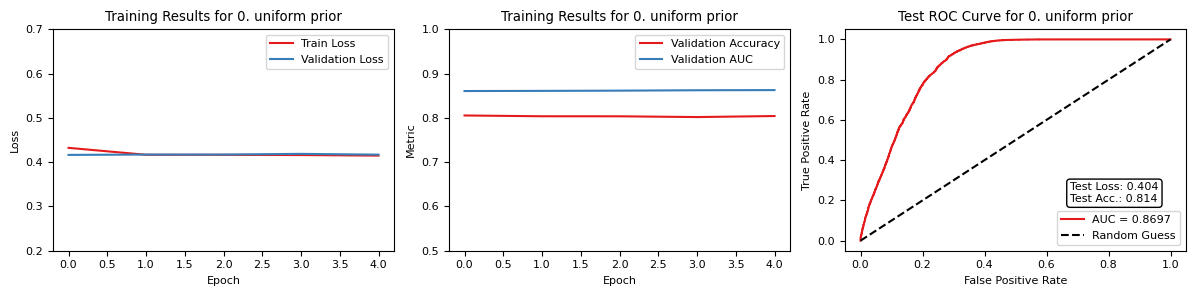

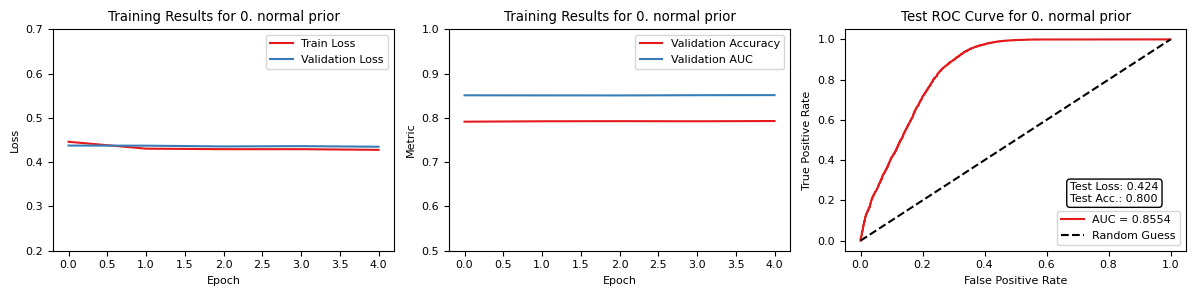

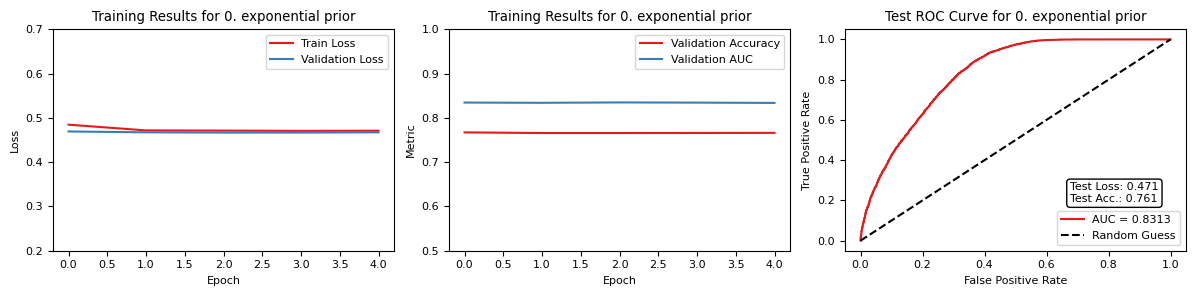

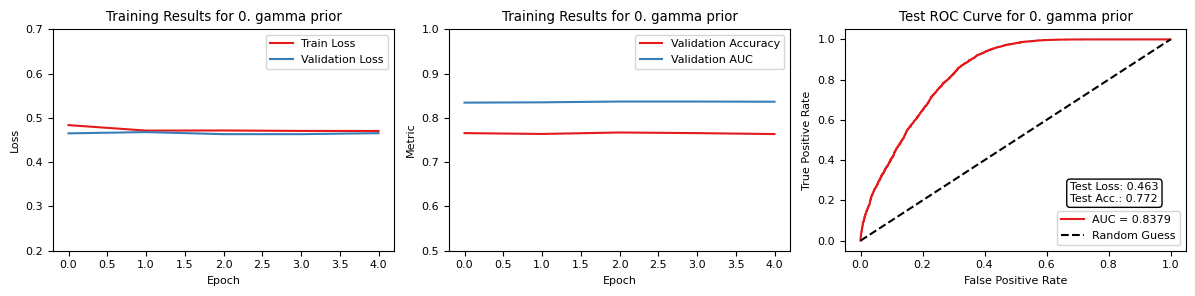

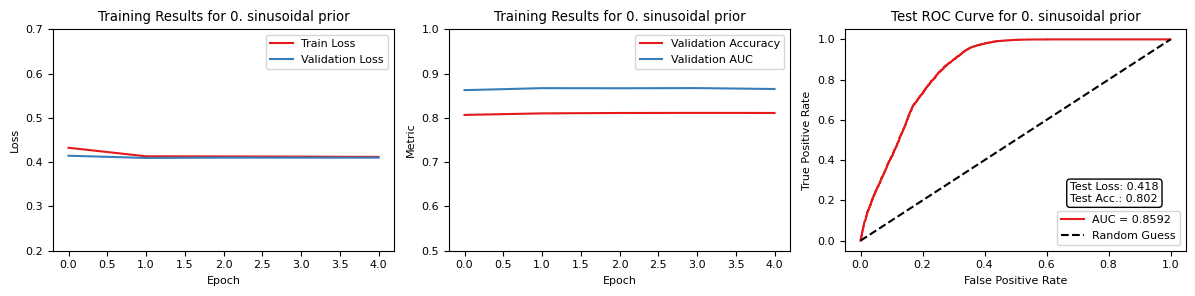

In [10]:
models = [[] for _ in range(config["training"]["model_iterations"])]
for prior in priors:
    for i in range(config["training"]["model_iterations"]):
        train_set, validation_set, test_set = get_data(prior=prior, show_output=False)
        model = BinaryClassifier(config)
        model, training_results = train(model, *train_set, *validation_set, show_output=False)
        filename_plots = get_filepath(f"training/training_{i}/training_{prior.__name__}_prior.svg", config)
        filename_model = get_filepath(f"models/models_{i}/model_{prior.__name__}_prior.pth", config)
        torch.save(model.state_dict(), filename_model)
        test_results = test_model(model, *test_set, show_output=False)
        plot_training_tests(training_results, test_results, f"{i}. {prior.__name__}", filename_plots)
        models[i] += [model]
    

#### Posterior:

In [11]:
def calculate_posteriors(model, prior, data_points, parameters_post):
    posteriors, ratios = [], []    
    for data_fixed in data_points:
        data_post = np.full(len(parameters_post), data_fixed)
        input_post = torch.cat(
            tensors=[torch.tensor(x).float().to(device).unsqueeze(1) for x in (data_post, parameters_post)],
            dim=1
        )
        model_out = model(input_post).cpu().detach().numpy().flatten()
        ratio = model_out / (1 - model_out)
        posterior = ratio * prior(parameters_post)
        posteriors += [posterior / np.trapezoid(posterior, parameters_post)]
        ratios += [ratio / np.trapezoid(ratio, parameters_post)]
    return posteriors, ratios

def area_above_k(k, theta, posterior_normalized):
    mask = posterior_normalized >= k
    if not np.any(mask):
        return 0.0
    area = np.trapezoid(posterior_normalized[mask], theta[mask])
    return area

def compute_hpd_interval(theta, posterior_normalized, alpha):
    def root_func(k):
        return area_above_k(k, theta, posterior_normalized) - (1 - alpha)
    # The posterior density values range from p_min to p_max
    p_min = np.min(posterior_normalized)
    p_max = np.max(posterior_normalized)
    # Ensure that func(k_lower) >= 0 and func(k_upper) <= 0
    k_lower = p_min
    k_upper = p_max
    # Adjust the bounds if necessary
    func_lower = root_func(k_lower)
    func_upper = root_func(k_upper)
    if func_lower < 0 or func_upper > 0:
        raise ValueError("Cannot find a valid k in the given range. Check the posterior and alpha.")
    # Use brentq to find k
    k = brentq(root_func, k_lower, k_upper, xtol=1e-12)
    # Identify the intervals where posterior >= k
    mask = posterior_normalized >= k
    indices = np.where(mask)[0]
    # Find contiguous intervals and store them in a NumPy array
    intervals = []
    if indices.size > 0:
        # Identify breaks in the sequence of indices
        breaks = np.where(np.diff(indices) > 1)[0]
        start_idx = 0
        breaks = np.append(breaks, len(indices) - 1)
        for break_idx in breaks:
            idx_range = indices[start_idx:break_idx + 1]
            theta_start = theta[idx_range[0]]
            theta_end = theta[idx_range[-1]]
            intervals.append([theta_start, theta_end])
            start_idx = break_idx + 1
    else:
        intervals = []
    # Convert intervals to a NumPy array
    intervals_array = np.array(intervals)
    return intervals_array

param_min, param_max = config["data"]["parameter_range"]
n_parameters=int(1e4)

def create_data_inputs(n_posterior, margin=1/4, data_is_random=False, samples_per_n_posterior=1, means_data=None):
    param_range = param_max - param_min
    if means_data is None:
        if data_is_random:
            means_data = generator.uniform(
                low=param_min+param_range*margin,
                high=param_max-param_range*margin,
                size=n_posterior
            )
        else:
            means_data = np.linspace(param_min+param_range*margin, param_max-param_range*margin, n_posterior)
    assert(len(means_data) == n_posterior)
    means_data = np.repeat(means_data, samples_per_n_posterior)
    data_inputs = generator.normal(loc=means_data, scale=config["data"]["std"], size=n_posterior*samples_per_n_posterior)
    return means_data, data_inputs

def calculate_individual_ratios(data, parameter):
    _, data_inputs = data
    parameters = parameter
    if isinstance(parameter, float) or isinstance(parameter, int):
        parameters = np.full(len(data_inputs), parameter)
    ratios = {}
    for model, prior in zip(models[0], priors):
        ratios_per_model = []
        for data_fixed, parameter_fixed in zip(data_inputs, parameters):
            input_post = torch.cat(
                tensors=[torch.tensor([x]).float().to(device).unsqueeze(1) for x in (data_fixed, parameter_fixed)],
                dim=1
            )
            model_out = model(input_post).cpu().detach().numpy().flatten()
            ratio = model_out / (1 - model_out)
            ratios_per_model += [ratio[0]]
        ratios[prior.__name__] = ratios_per_model
    return ratios
    

def get_posteriors_and_errors(data, parameters_post):
    means_data, data_inputs = data
    samples_per_n_posterior = len(data_inputs) // len(np.unique(means_data))
    all_posteriors = {}
    all_HPDs = {}
    all_ratios = {}
    for model, prior in zip(models[0], priors):
        posteriors, ratios = calculate_posteriors(
            model,
            prior,
            data_inputs,
            parameters_post
        )
        ratios_grouped, posteriors_grouped = [], []
        for i in range(0, len(posteriors), samples_per_n_posterior):
            posteriors_to_multipy = posteriors[i:i+samples_per_n_posterior]
            posterior_product = np.prod(posteriors_to_multipy, axis=0)
            posterior_product /= np.trapezoid(posterior_product, parameters_post)
            posteriors_grouped += [posterior_product]
            ratios_to_multiply = ratios[i:i+samples_per_n_posterior]
            ratio_product = np.prod(ratios_to_multiply, axis=0)
            ratio_product /= np.trapezoid(ratio_product, parameters_post)
            ratios_grouped += [ratio_product]
        errors = []
        for posterior in posteriors_grouped:
            hpd_68 = compute_hpd_interval(
                parameters_post,
                posterior,
                alpha=0.32
            )
            hpd_95 = compute_hpd_interval(
                parameters_post,
                posterior,
                alpha=0.05
            )
            errors += [{"68": hpd_68, "95": hpd_95}]
        all_HPDs[prior.__name__] = errors
        all_posteriors[prior.__name__] = posteriors_grouped
        all_ratios[prior.__name__] = ratios_grouped
    return all_posteriors, all_HPDs, all_ratios

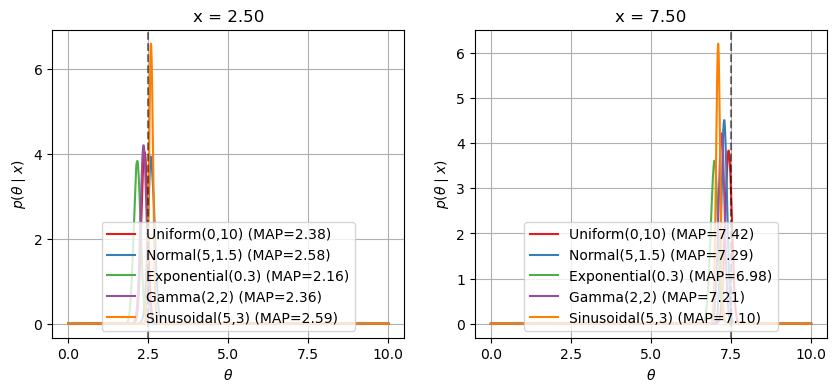

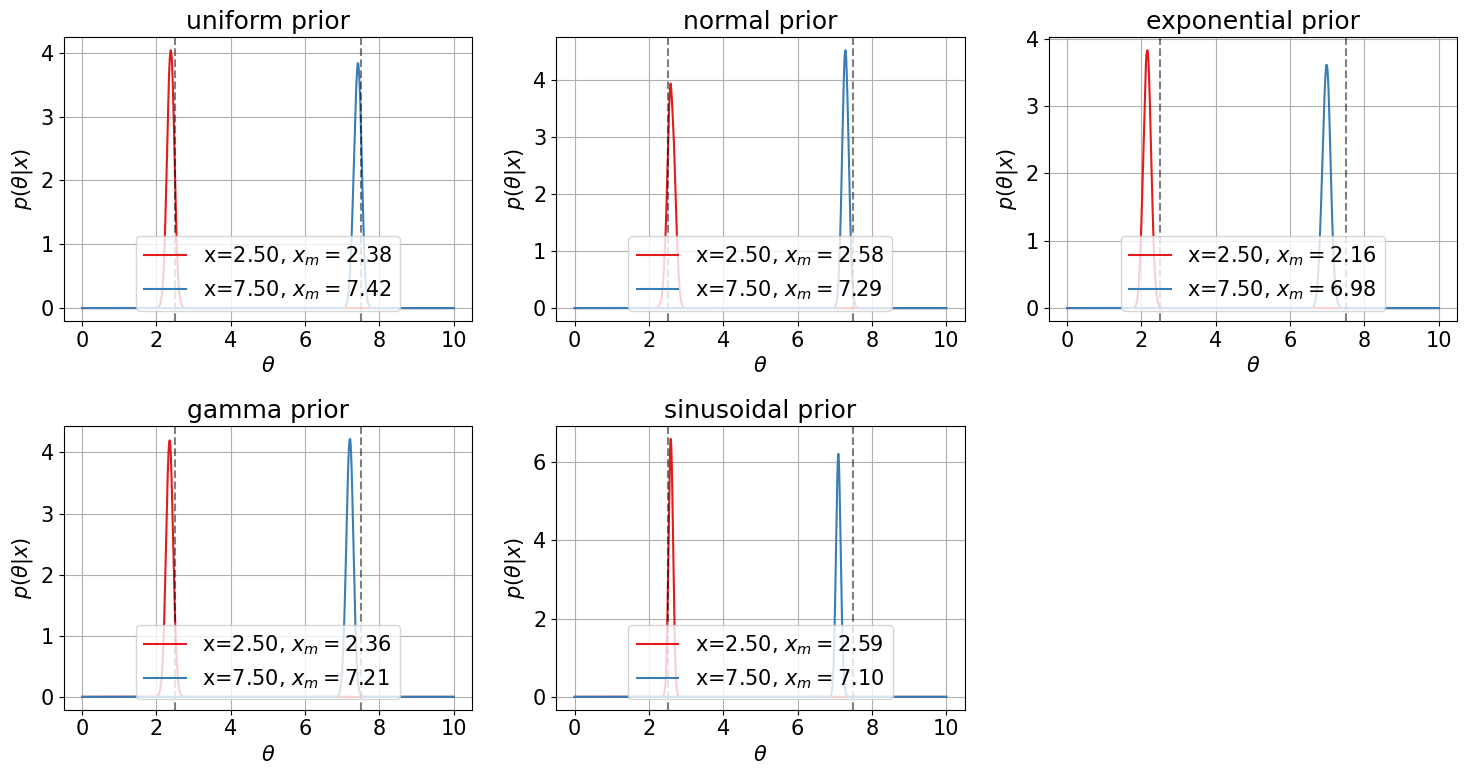

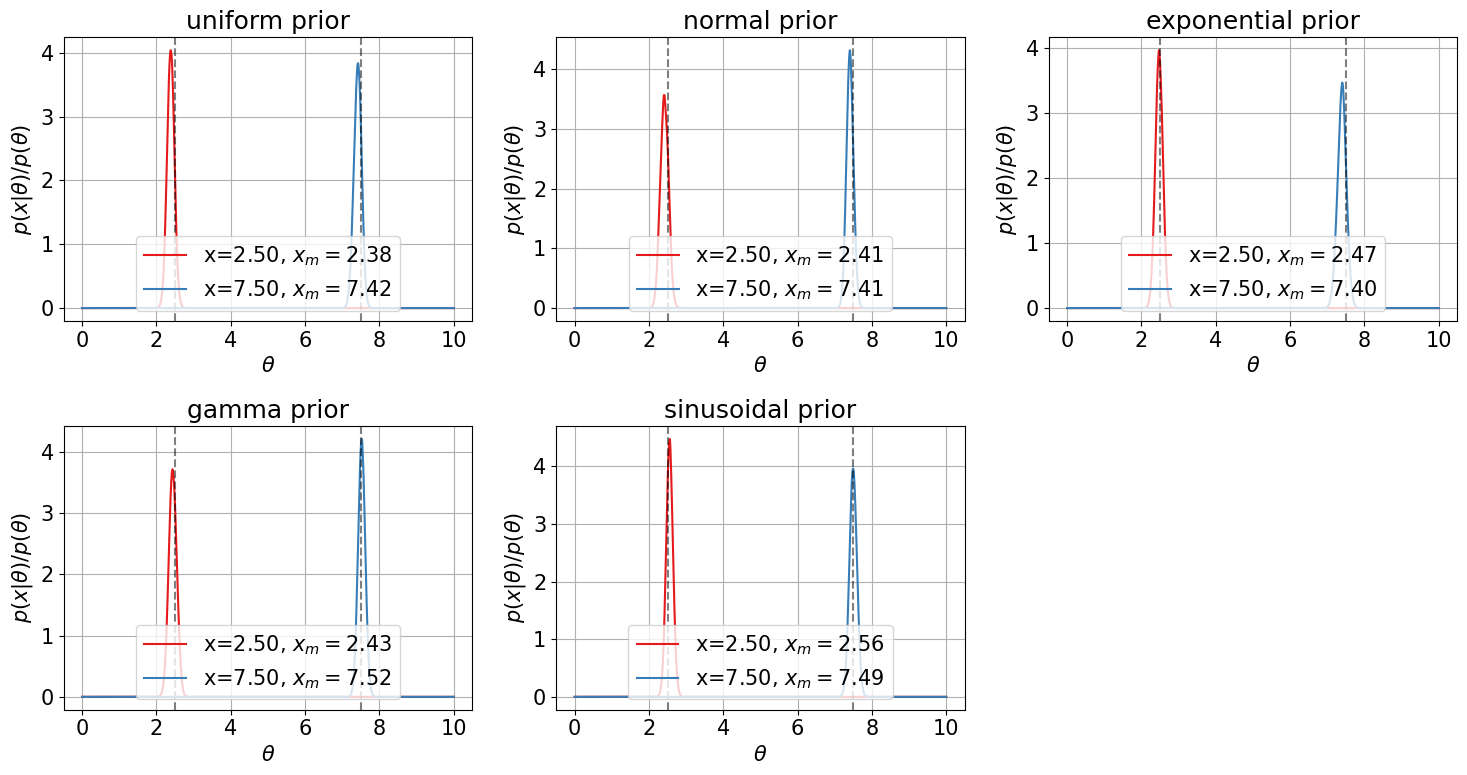

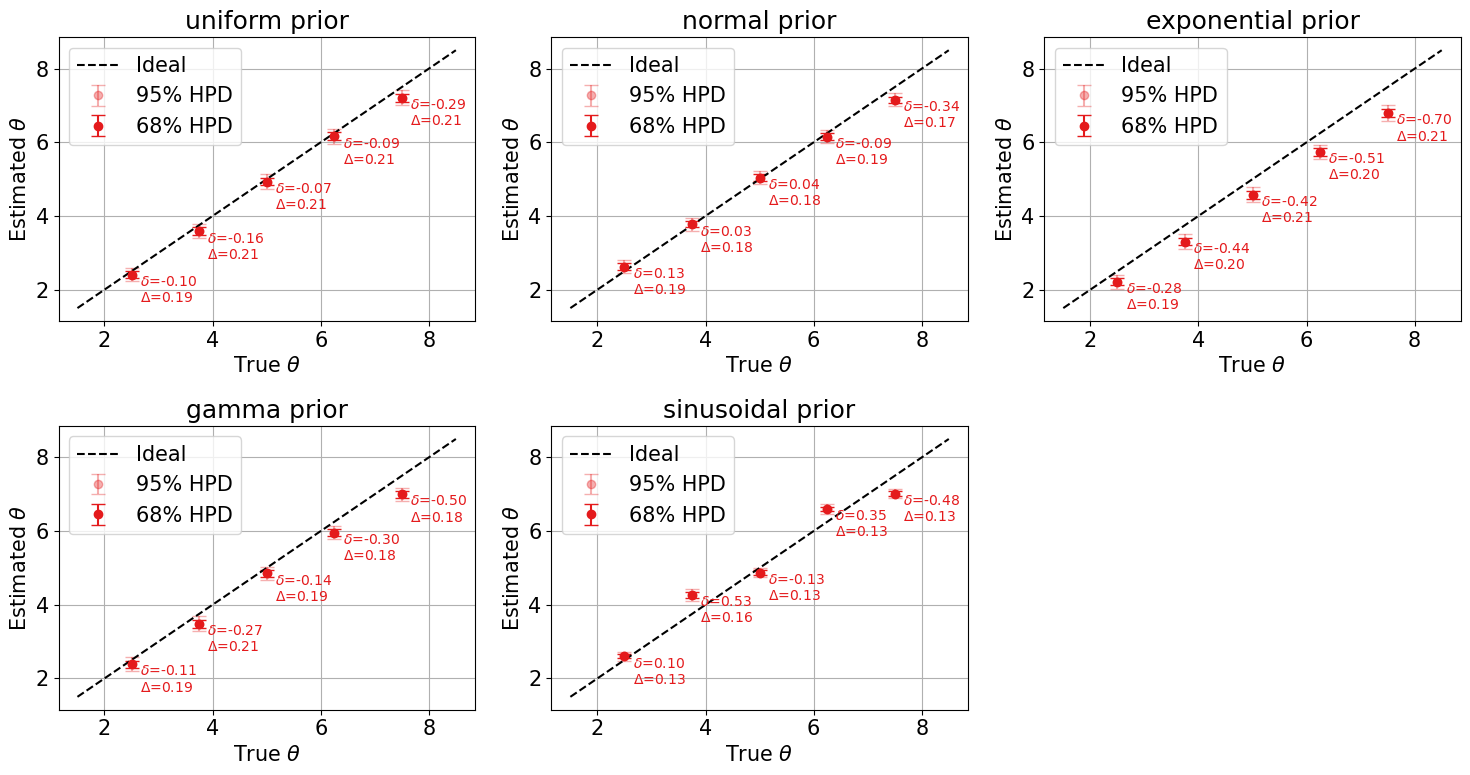

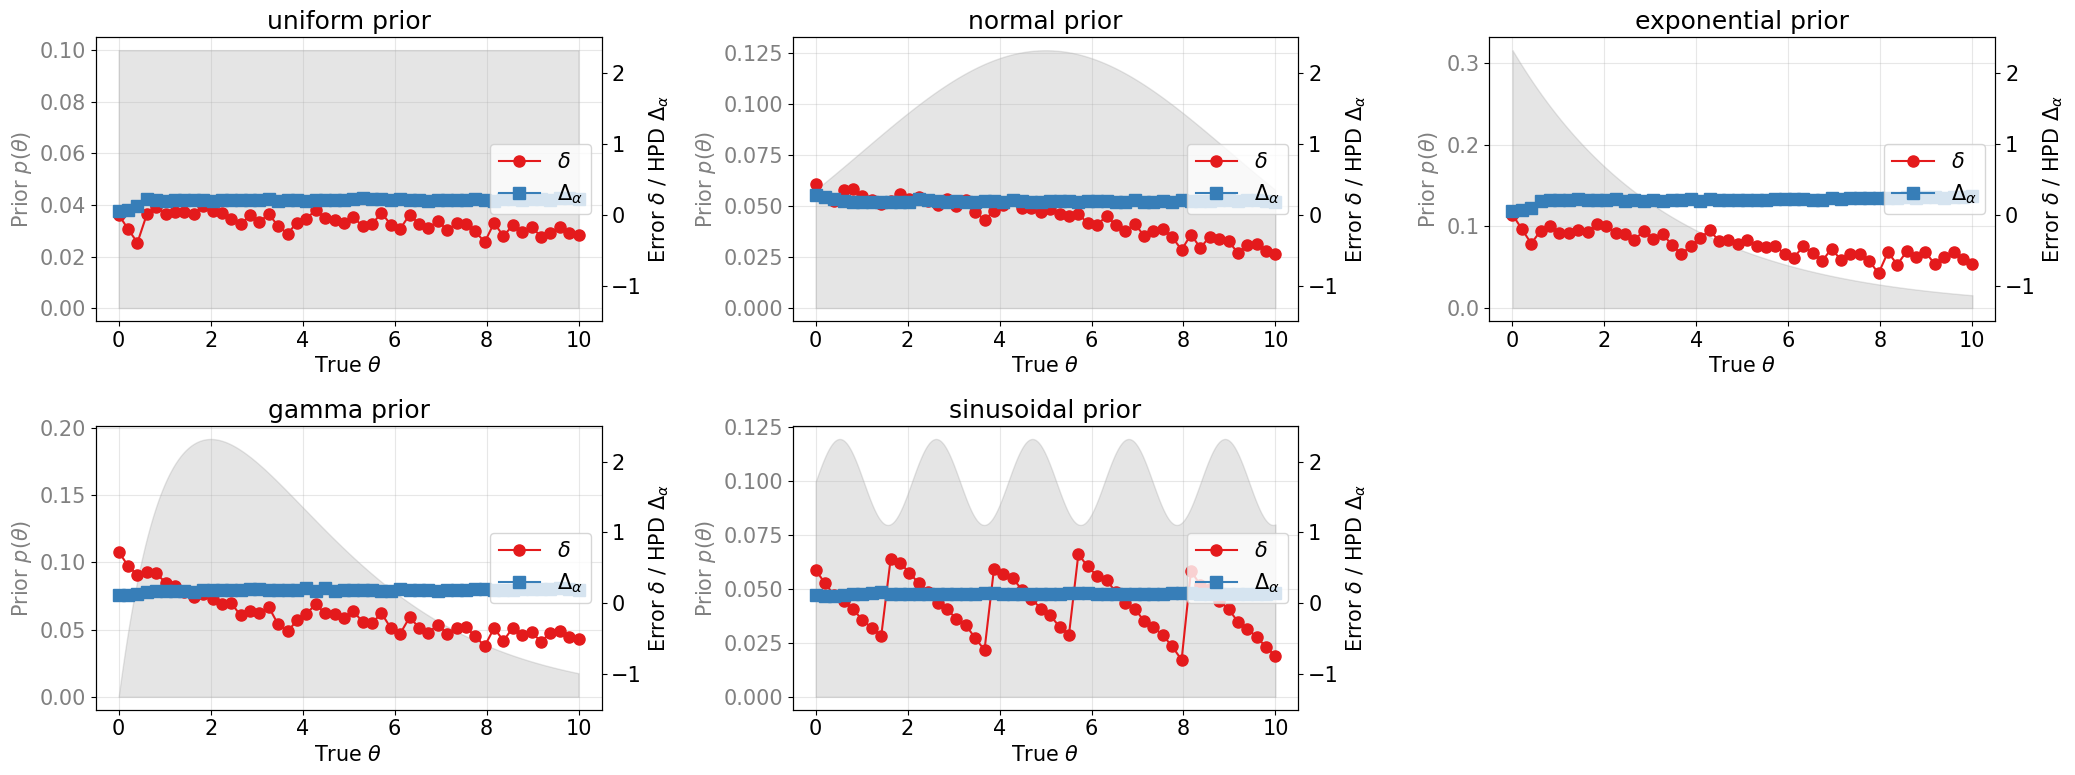

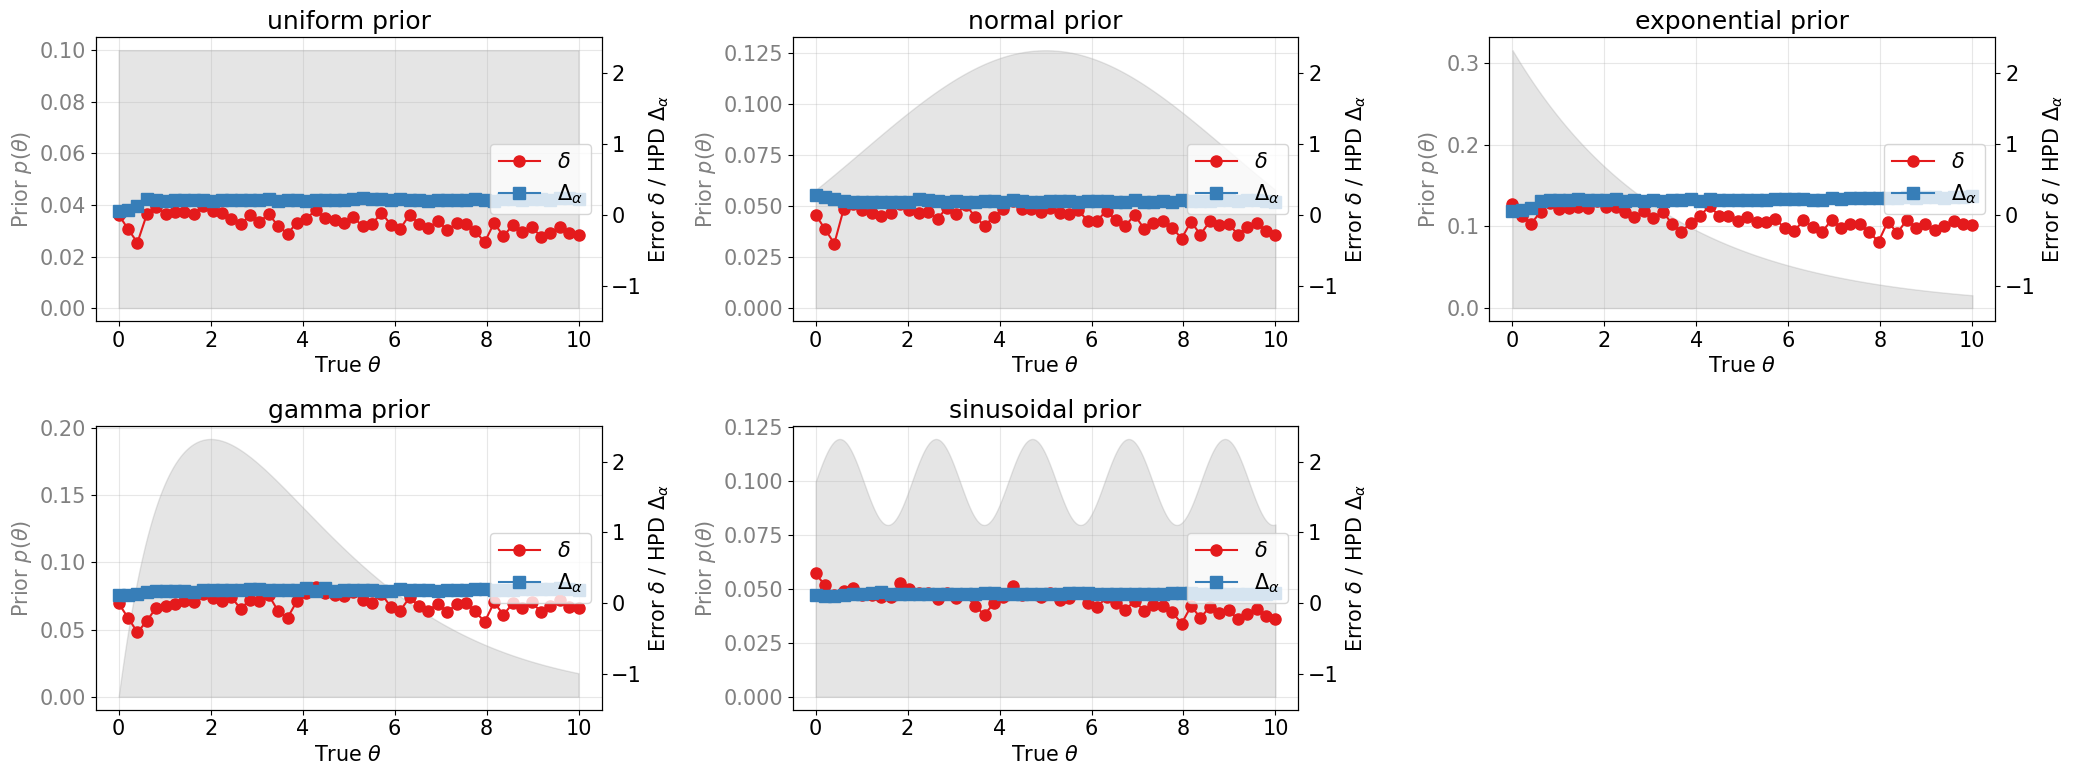

In [ ]:
save = True
filename_parameter_per_prior = get_filepath(f"posterior_errors/parameter_per_prior.svg", config) if save else None
filename_prior_per_parameter = get_filepath(f"posterior_errors/prior_per_parameter.svg", config) if save else None
filename_prior_per_ratios = get_filepath(f"posterior_errors/prior_per_ratios.svg", config) if save else None
filename_errorbars = get_filepath(f"posterior_errors/errorbars.svg", config) if save else None
filename_error_and_hpd_width = get_filepath(f"posterior_errors/error_and_hpd_width.svg", config) if save else None
filename_error_and_hpd_width_ratios = get_filepath(f"posterior_errors/error_and_hpd_width_ratios.svg", config) if save else None

parameters_post = np.linspace(param_min, param_max, n_parameters)
data_inputs = create_data_inputs(n_posterior=2, samples_per_n_posterior=10)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(data_inputs, parameters_post)
plot_parameter_per_prior(all_posteriors, parameters_post, data_inputs, filename=filename_parameter_per_prior)
plot_prior_per_parameter(all_posteriors, parameters_post, data_inputs, filename=filename_prior_per_parameter)
plot_prior_per_ratios(all_ratios, parameters_post, data_inputs, filename=filename_prior_per_ratios)

data_inputs = create_data_inputs(n_posterior=5, samples_per_n_posterior=10)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(data_inputs, parameters_post)
plot_errorbars(all_HPDs, data_inputs, all_posteriors, parameters_post, filename=filename_errorbars)

data_inputs = create_data_inputs(n_posterior=50, margin=0, samples_per_n_posterior=100)
all_posteriors, all_HPDs, all_ratios = get_posteriors_and_errors(data_inputs, parameters_post)
plot_error_and_hpd_width(all_HPDs, data_inputs, all_posteriors, parameters_post, priors, filename=filename_error_and_hpd_width)
plot_error_and_hpd_width(all_HPDs, data_inputs, all_ratios, parameters_post, priors, filename=filename_error_and_hpd_width_ratios)

#### Posterior Checks:

Check I: ratio expectation value

$1=\int p(x|\theta_0) dx = \int r(x|\theta_0) p(x) dx = \mathbb{E} [r(x|\theta_0)]$

i.e. if $\mathbb{E} [r(x|\theta_0)]=1$, then $r(x|\theta_0) = p(x|\theta_0) / p(x) = p(\theta_0 | x) / p(\theta_0)$ is plausible

In [13]:
def calculate_all_ratios(data_inputs, test_parameters):
    all_ratios = {}
    for parameter in test_parameters:
        ratios = calculate_individual_ratios(data_inputs, parameter)
        for prior_name, ratio_values in ratios.items():
            if prior_name not in all_ratios:
                all_ratios[prior_name] = []
            all_ratios[prior_name] += [ratio_values]
    return all_ratios

In [14]:
data_inputs = create_data_inputs(n_posterior=1000, margin=0, data_is_random=True, samples_per_n_posterior=1)
test_parameters = np.linspace(param_min, param_max, 5)
all_ratios = calculate_all_ratios(data_inputs, test_parameters)

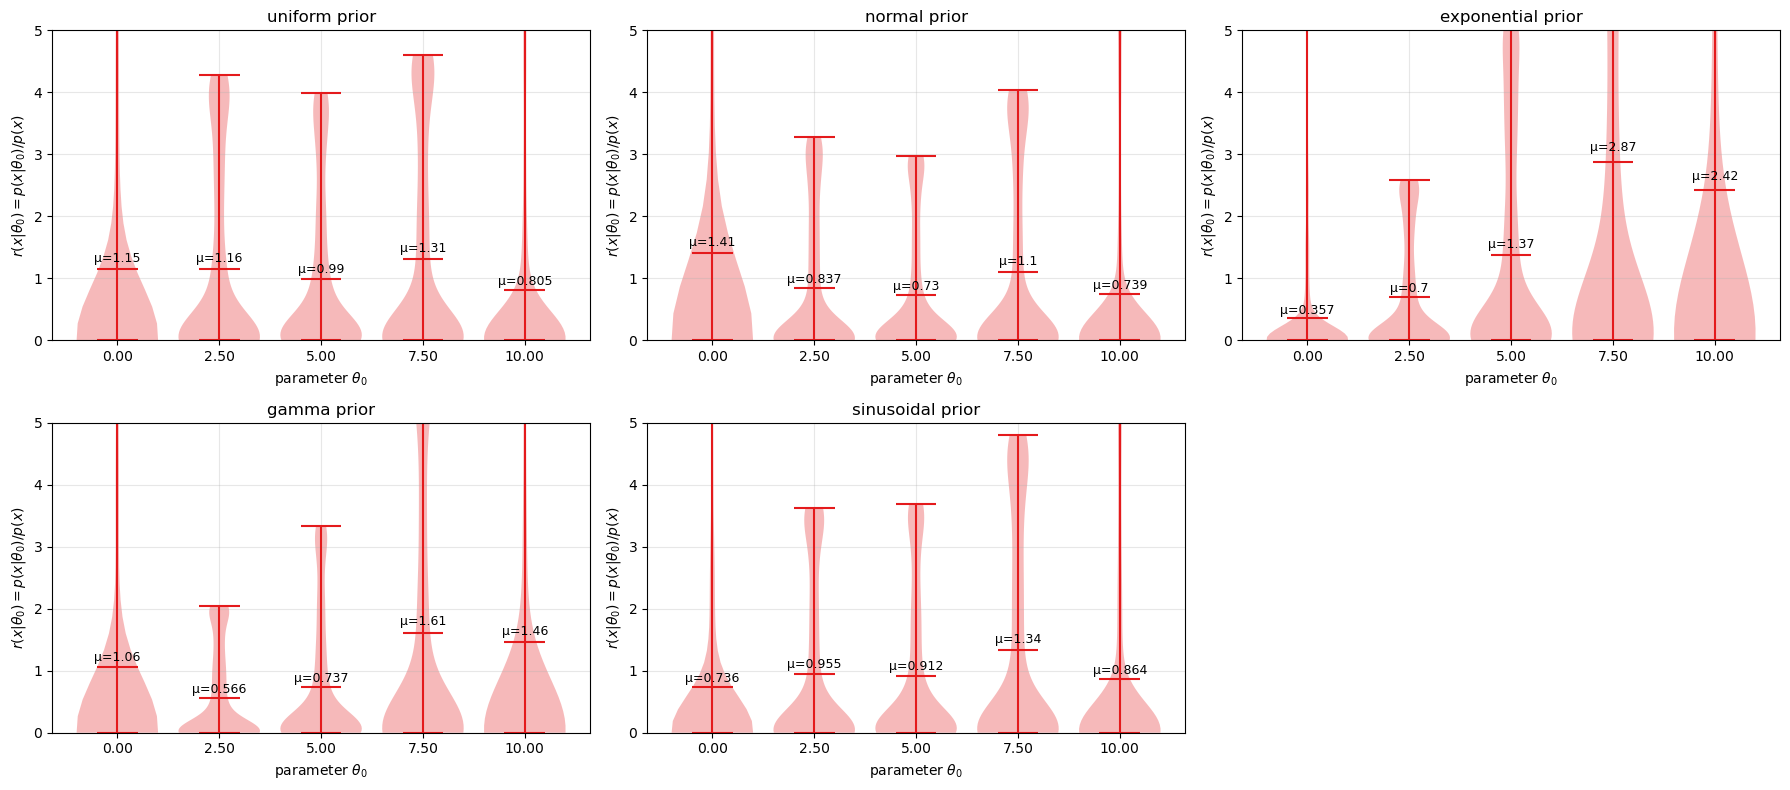

In [15]:
filename_ratio_violins = get_filepath(f"verifications/ratio_violins.svg", config) if save else None
plot_ratio_violins(all_ratios, test_parameters, filename=filename_ratio_violins)

Check II: reweighting

$R_{10}(x) = \frac{r(x|\theta_1)}{r(x|\theta_0)} = \frac{p(x|\theta_1)}{p(x|\theta_0)}$

if $p(x|\theta_1) = R_{10}(x)p(x|\theta_0)$: likelihood ratio trick holds

In [16]:
def compute_ratio(data, parameter, model):
    def _to_array_or_scalar(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        if np.isscalar(x):
            return x, 'scalar'
        x = np.asarray(x)
        assert x.ndim == 1, "Expected 1D input when passing an array-like."
        return x, 'vector'

    data_point, _t_data = _to_array_or_scalar(data)
    parameters, _t_param = _to_array_or_scalar(parameter)

    if _t_data == 'scalar' and _t_param == 'vector':
        data_point = np.full(parameters.shape, data_point, dtype=float)
    elif _t_data == 'vector' and _t_param == 'scalar':
        parameters = np.full(data_point.shape, parameters, dtype=float)
    elif _t_data == 'vector' and _t_param == 'vector':
        assert len(data_point) == len(parameters), "data and parameter must have the same length."
    elif _t_data == 'scalar' and _t_param == 'scalar':
        data_point = [data_point]
        parameters = [parameter]
    
    model_in = torch.cat(
        tensors=[torch.tensor(x).float().to(device).unsqueeze(1) for x in (data_point, parameters)],
        dim=1
    )
    model_out = model(model_in).cpu().detach().numpy().flatten()
    ratio = model_out / (1 - model_out)
    return ratio, model_out

def reweight_distributions(test_parameters, model_arr, n_test_data= int(1e6), n_bins=int(1e3)):
    all_ratios = {}
    all_outs = {}
    reweighting_distributions = {}
    reweighted_distributions = {}
    data_x = [generator.normal(loc=parameter, scale=config["data"]["std"], size=n_test_data) for parameter in test_parameters]
    for prior, model in zip(priors, model_arr):
        results = [compute_ratio(data_x[0], parameter, model) for parameter in test_parameters]
        ratios = [result[0] for result in results]
        model_outs = [result[1] for result in results]
        all_ratios[prior.__name__] = ratios
        all_outs[prior.__name__] = model_outs
        reweighting_distributions[prior.__name__] = ratios[1] / ratios[0]
        reweighted_distribution, edges = np.histogram(
            data_x[0],
            bins=n_bins,
            weights=reweighting_distributions[prior.__name__],
            density=False,
            range=config["data"]["parameter_range"]
        )
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        reweighted_distributions[prior.__name__] = (bin_centers, reweighted_distribution)
    return data_x, reweighted_distributions, reweighting_distributions, all_outs

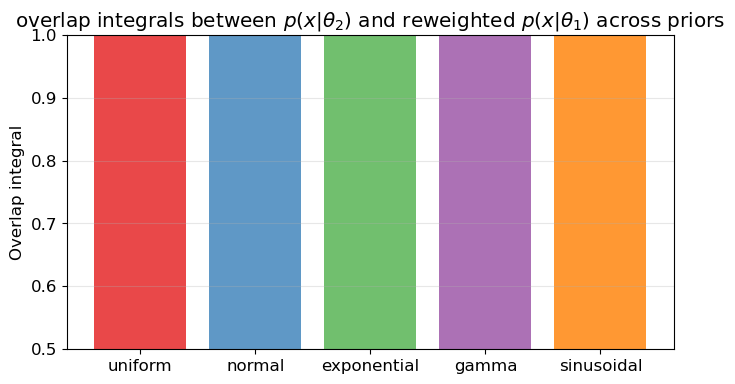

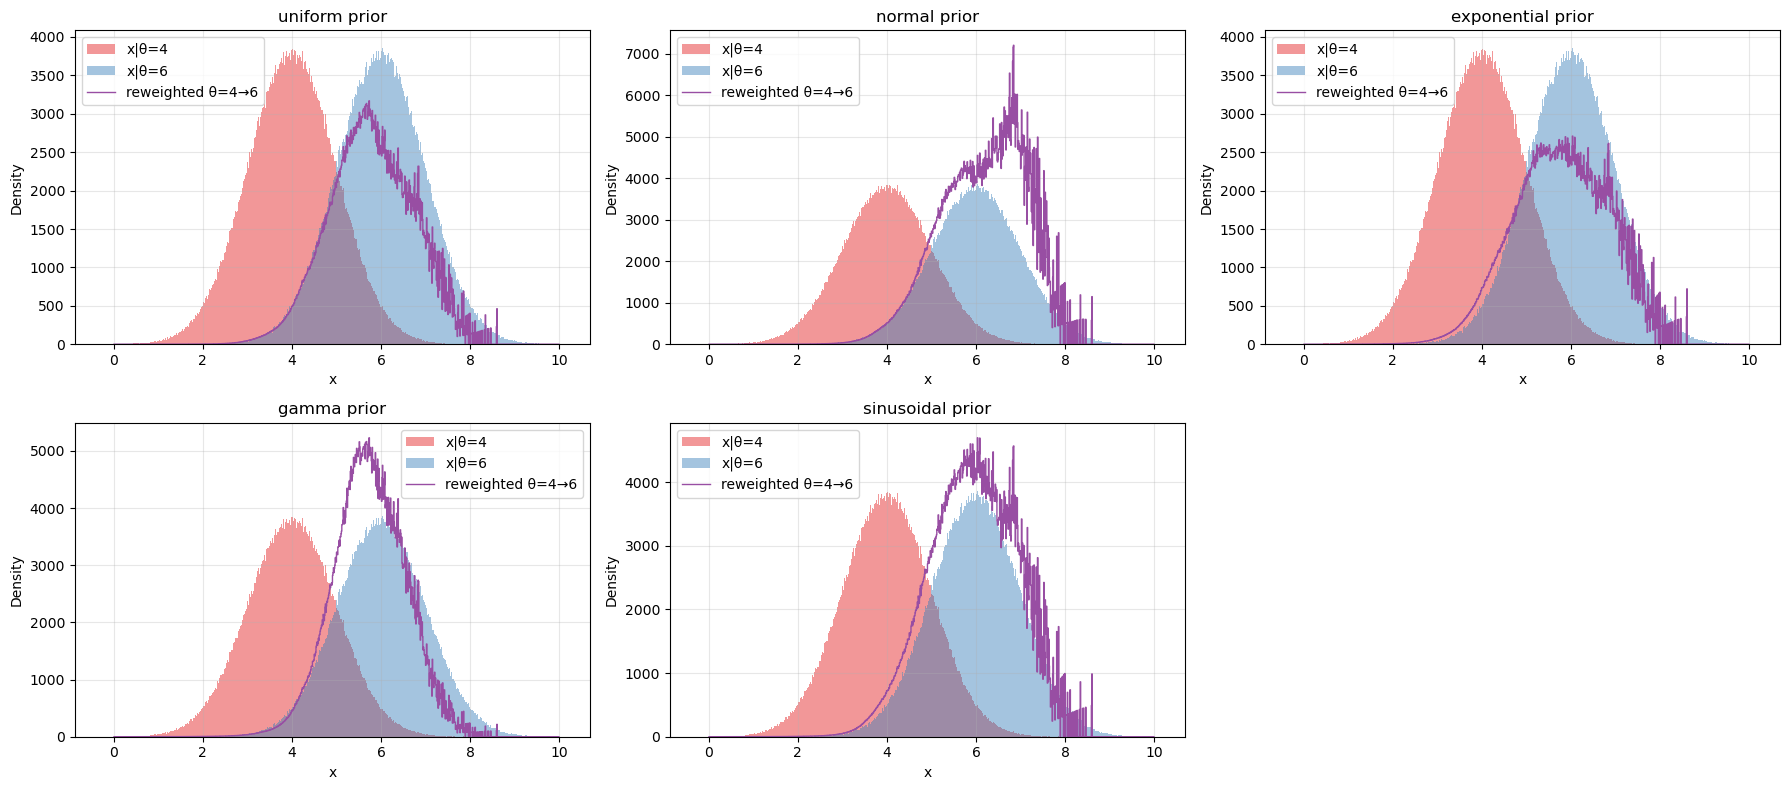

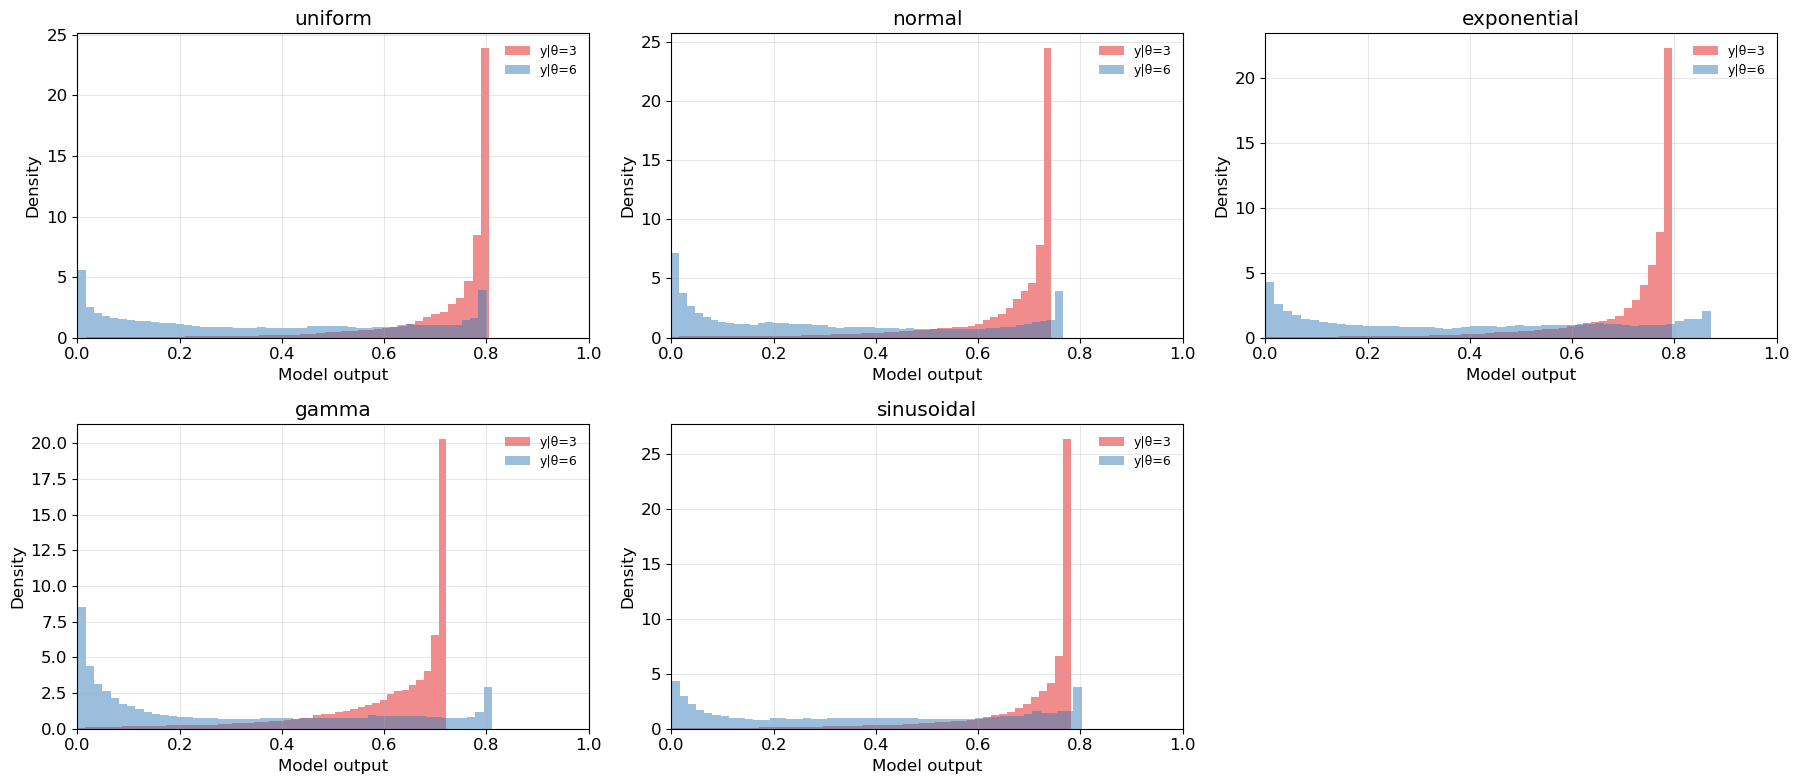

In [17]:
n_test_data = int(1e6)
n_bins = int(1e3)
test_parameters = [(4, 6)]#[(2, 3), (5, 6)] #, (7, 8), (4, 7), (6, 4)]
for i, model_arr in enumerate(models):
    for test_parameter_set in test_parameters:
        data_x, reweighted_distributions, reweighting_distributions, all_outs = reweight_distributions(test_parameter_set, model_arr, n_test_data, n_bins)
        filename_overlap_integrals = get_filepath(f"verifications/reweighting_{i}/overlap_integrals_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        filename_reweighted_distributions = get_filepath(f"verifications/reweighting_{i}/reweighted_distributions_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=filename_overlap_integrals)
        plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameter_set, n_bins, filename=filename_reweighted_distributions)
        plot_all_outs_histograms(all_outs, (3, 6), n_bins=50, filename=None)

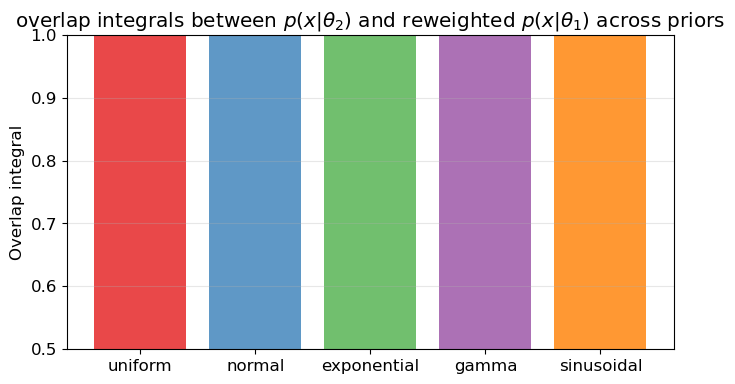

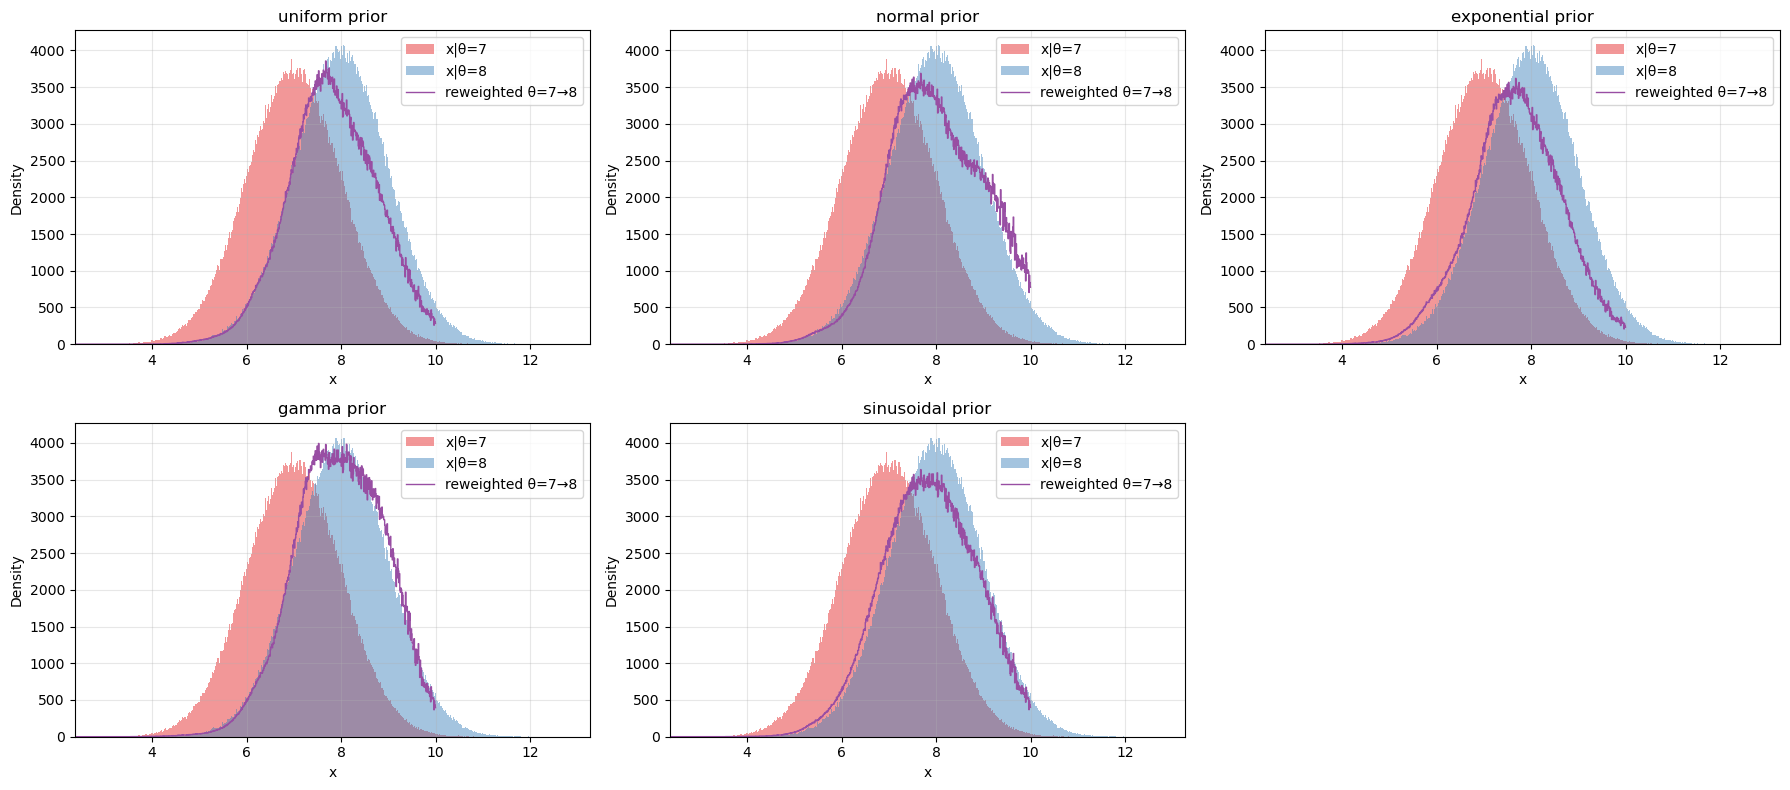

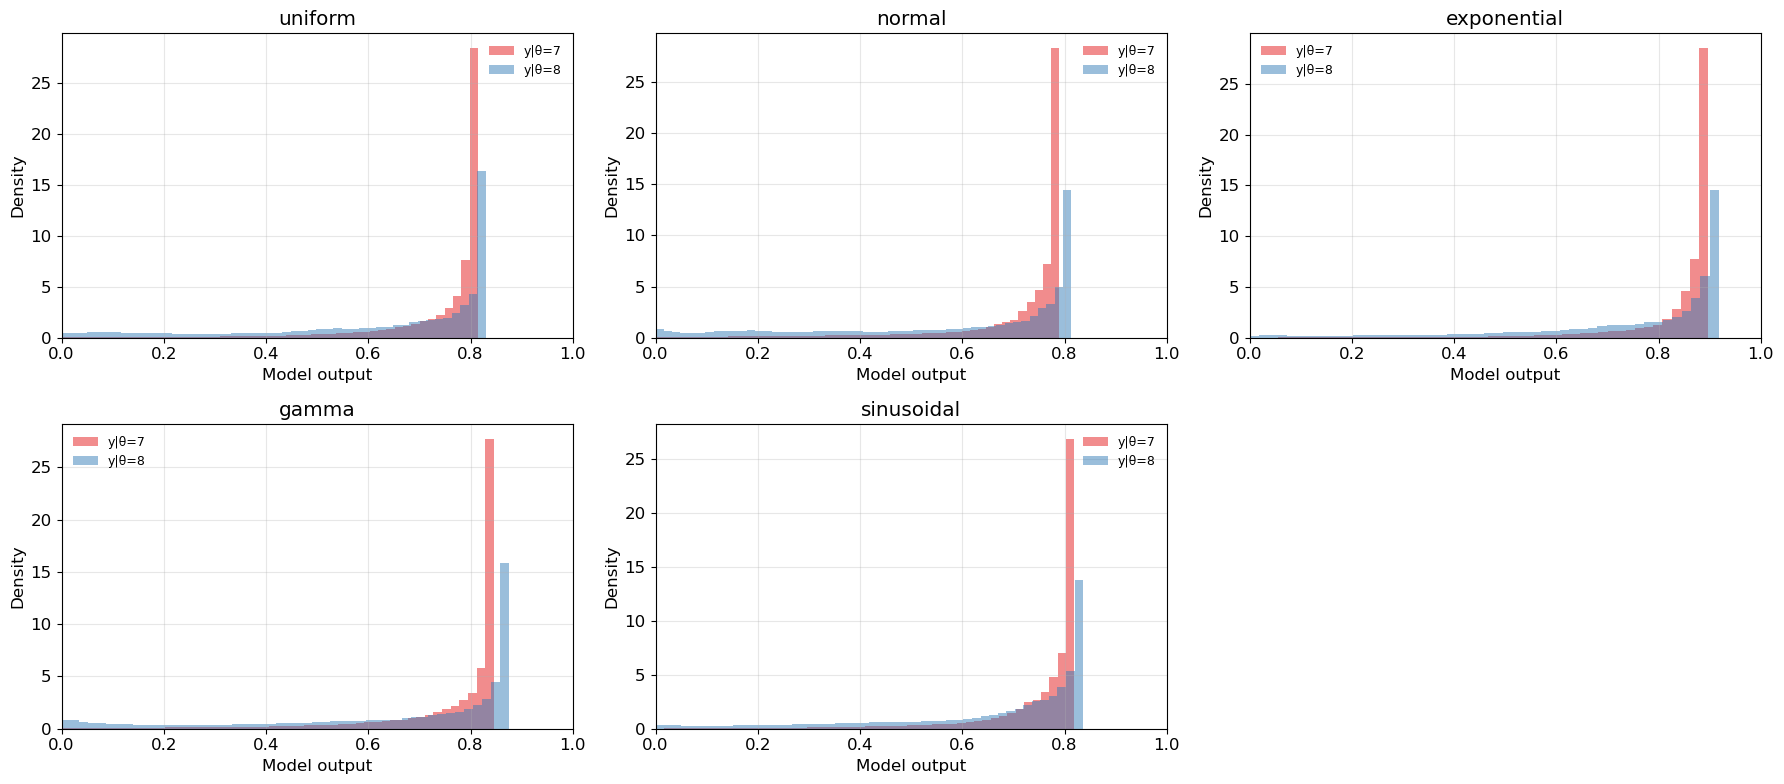

In [18]:
n_test_data = int(1e6)
n_bins = int(1e3)
test_parameters = [(7, 8)] #[(2, 3), (5, 6)] #, (7, 8), (4, 7), (6, 4)]
for i, model_arr in enumerate(models):
    for test_parameter_set in test_parameters:
        data_x, reweighted_distributions, reweighting_distributions, all_outs = reweight_distributions(test_parameter_set, model_arr, n_test_data, n_bins)
        filename_overlap_integrals = get_filepath(f"verifications/reweighting_{i}/overlap_integrals_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        filename_reweighted_distributions = get_filepath(f"verifications/reweighting_{i}/reweighted_distributions_{test_parameter_set[0]}_{test_parameter_set[1]}.svg", config) if save else None
        plot_overlap_integrals_per_prior(data_x, reweighting_distributions, priors, n_bins, filename=filename_overlap_integrals)
        plot_reweighted_distributions(priors, data_x, reweighted_distributions, test_parameter_set, n_bins, filename=filename_reweighted_distributions)
        plot_all_outs_histograms(all_outs, test_parameter_set, n_bins=50, filename=None)